In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import numpy as np
import pandas as pd
import itertools as it
import networkx as nx
import matplotlib.pyplot as plt


from finite_groups import *
from induced_rep_solver import *

# from activation_funcs import *

def RELU(x): return sp.Max(0, x)
def TANH(x): return sp.tanh(x)
def SIGMOID(x): return 1 / (1 + sp.exp(-x))
def LINEAR(x): return x

In [2]:
# ==============================================================================
# HELPER: S4 DATA GENERATION
# ==============================================================================
def get_s4_data():
    """Generates S4 elements, classes, and characters for use in the main logic."""
    # 1. Elements
    perms = list(it.permutations(range(4)))
    
    # 2. Representatives & Classes (Manual definitions for standard S4)
    # 1A: Identity
    rep_1a = (0, 1, 2, 3) 
    # 2A: Transposition (0 1)
    rep_2a = (1, 0, 2, 3)
    # 3A: 3-Cycle (0 1 2)
    rep_3a = (1, 2, 0, 3)
    # 2B: Double Transposition (0 1)(2 3)
    rep_2b = (1, 0, 3, 2)
    # 4A: 4-Cycle (0 1 2 3)
    rep_4a = (1, 2, 3, 0)

    reps = [rep_1a, rep_2a, rep_3a, rep_2b, rep_4a]
    
    # 3. Character Table Rows (1, Sign, Deg2, Std, Std*Sign)
    # Cols: 1A, 2A, 3A, 2B, 4A
    chars = [
        [1,  1,  1,  1,  1], # Chi1 (Triv)
        [1, -1,  1,  1, -1], # Chi2 (Sign)
        [2,  0, -1,  2,  0], # Chi3 (Deg2)
        [3,  1,  0, -1, -1], # Chi4 (Std)
        [3, -1,  0, -1,  1]  # Chi5 (Std*Sign)
    ]
    
    return perms, reps, chars

# ==============================================================================
# SECTION 1: DEFINE GROUP (G = C3 x S4)
# ==============================================================================
def define_group():
    """
    Define G = C3 x S4.
    Elements are tuples (c, p) where c is int, p is tuple.
    """
    s4_perms, _, _ = get_s4_data()
    c2_elems = [0,1,2]
    
    # Cross product
    elements = []
    for c in c2_elems:
        for p in s4_perms:
            elements.append((c, p))
            
    def mult_func(e1, e2):
        # e1 = (c1, p1), e2 = (c3, p2)
        c1, p1 = e1
        c2, p2 = e2
        
        # Add C3 part
        c_new = (c1 + c2) % 3
        
        # Multiply S4 part: p_new[i] = p1[p2[i]]
        p_new = tuple(p1[x] for x in p2)
        
        return (c_new, p_new)

    return elements, mult_func

# ==============================================================================
# SECTION 2: DEFINE SUBGROUP (H)
# ==============================================================================
def define_subgroup(G: FiniteGroup):
    """
    Define H. We choose H isomorphic to S3 inside the S4 component, 
    and trivial inside C3.
    H = { (1, p) | p in S4, p(3) = 3 }
    Index = 72 / 6 = 12.
    """
    H = []
    
    # We can iterate G elements and check the condition
    for g in G.elements:
        c, p = g
        # Condition: C3 part is identity (0) AND S4 part fixes element 3
        if c == 0 and p[3] == 3:
            H.append(g)
            
    return H

# ==============================================================================
# SECTION 3: DEFINE CONJUGACY CLASSES (MANUAL)
# ==============================================================================
def define_conjugacy_classes():
    """
    Generate 10 classes for C3 x S4.
    Classes are (c_class) x (s4_class).
    """
    s4_perms, s4_reps, _ = get_s4_data()
    
    # Helper to find full class members in S4 for a rep
    # (We re-generate them simply to provide the full list to the solver)
    # Note: For S4, conjugation p * x * p_inv
    def get_class_members(rep):
        members = set()
        rep_inv = [0]*4
        for i, val in enumerate(rep): rep_inv[val] = i
        rep_inv = tuple(rep_inv)
        
        # Conjugate by all s4 perms
        for p in s4_perms:
            # p * rep * p^-1
            # calc p_inv
            p_inv = [0]*4
            for i, val in enumerate(p): p_inv[val] = i
            
            # rep * p_inv
            step1 = tuple(rep[x] for x in p_inv)
            # p * step1
            conj = tuple(p[x] for x in step1)
            members.add(conj)
        return list(members)

    classes = []
    
    # Iterate C3 components
    for c in [0,1,2]:
        # Iterate S4 components
        for rep in s4_reps:
            full_rep = (c, rep)
            
            # Build members list
            s4_members = get_class_members(rep)
            full_members = [(c, m) for m in s4_members]
            
            classes.append( (full_rep, full_members) )
            
    return classes

# ==============================================================================
# SECTION 4: CHARACTER TABLE (C3 x S4)
# ==============================================================================
def define_character_table():
    """
    Generate 15x15 table via tensor product.
    Using standard complex representations for C3.
    """
    _, s4_reps, s4_chars = get_s4_data()
    
    # Complex root of unity
    w = sp.exp(2 * sp.pi * sp.I / 3)
    w2 = sp.exp(4 * sp.pi * sp.I / 3)
    
    # Standard Complex C3 Chars:
    c3_chars = [
        {0: 1, 1: 1,  2: 1},   # 1: Trivial
        {0: 1, 1: w,  2: w2},  # omega: Complex 1D
        {0: 1, 1: w2, 2: w}    # omega^2: Complex conjugate 1D (omega*)
    ]
    
    char_map = {}
    labels = []
    
    for c3_chi in c3_chars:
        for s4_chi_row in s4_chars:
            for c_val in [0,1,2]:
                for i, rep in enumerate(s4_reps):
                    full_rep = (c_val, rep)
                    val = c3_chi[c_val] * s4_chi_row[i]
                    
                    if full_rep not in char_map:
                        char_map[full_rep] = []
                    char_map[full_rep].append(val)
    
    s4_labels = ["1", "1111", "22", "31", "211"]
    c3_labels = ["1", "\omega", "\omega^2"] 
    
    for l1 in c3_labels:
        for l2 in s4_labels:
            labels.append(rf"${l2}^{{{l1}}}$")

    return char_map, labels

<>:173: SyntaxWarning: invalid escape sequence '\o'
<>:173: SyntaxWarning: invalid escape sequence '\o'
<>:173: SyntaxWarning: invalid escape sequence '\o'
<>:173: SyntaxWarning: invalid escape sequence '\o'
/var/folders/dv/1fh0mhbj1lq5yk_27yzzwc040000gn/T/ipykernel_1704/3691413326.py:173: SyntaxWarning: invalid escape sequence '\o'
  c3_labels = ["1", "\omega", "\omega^2"]
/var/folders/dv/1fh0mhbj1lq5yk_27yzzwc040000gn/T/ipykernel_1704/3691413326.py:173: SyntaxWarning: invalid escape sequence '\o'
  c3_labels = ["1", "\omega", "\omega^2"]


In [3]:
def c3_irreps():
    """Explicit complex 1D matrices for C3"""
    w = sp.exp(2 * sp.pi * sp.I / 3)
    w2 = sp.exp(4 * sp.pi * sp.I / 3)
    
    return {
        "1": lambda c: sp.Matrix([[1]]),       
        "\omega": lambda c: sp.Matrix([[w**c]]),    
        "\omega^2": lambda c: sp.Matrix([[w2**c]])    
    }


def s4_trivial(p):
    return sp.Matrix([[1]])

def s4_sign(p):
    # sign = (-1)^(number of inversions)
    inv = 0
    for i in range(4):
        for j in range(i+1, 4):
            if p[i] > p[j]:
                inv += 1
    return sp.Matrix([[1 if inv % 2 == 0 else -1]])

def s4_standard(p):
    # permutation matrix 4x4
    P = sp.zeros(4,4)
    for i in range(4):
        P[p[i], i] = 1

    # basis change matrix B (4x3)
    B = sp.Matrix([
        [1,0,0],
        [0,1,0],
        [0,0,1],
        [-1,-1,-1]
    ])

    # representation = B^T P B
    return (B.T * P * B)

def s4_standard_sign(p):
    return s4_standard(p) * s4_sign(p)[0]

def s4_2d_rep(p):
    # act on unordered pairs {i,j}
    pairs = [(0,1),(0,2),(0,3),(1,2),(1,3),(2,3)]
    
    P = sp.zeros(6,6)
    for i, pair in enumerate(pairs):
        image = tuple(sorted((p[pair[0]], p[pair[1]])))
        j = pairs.index(image)
        P[j,i] = 1
    
    # remove trivial and standard components
    # basis reduction via character projection later
    return P


def build_irrep_mats(G: FiniteGroup):
    c3_maps = c3_irreps()
    irrep_mats = {}
    
    s4_funcs = {
        "1": s4_trivial,
        "1111": s4_sign,
        "22": s4_2d_rep,
        "31": s4_standard,
        "211": s4_standard_sign
    }

    for sign_label in ["1", "\omega", "\omega^2"]:
        for s4_label in ["1","1111","22","31","211"]:

            full_label = rf"${s4_label}^{{{sign_label}}}$"
            irrep_mats[full_label] = {}

            for g in G.elements:
                c, p = g
                g_key = G._key(g)

                rho_c2 = c3_maps[sign_label](c)
                rho_s4 = s4_funcs[s4_label](p)

                # Tensor product
                rho = sp.kronecker_product(rho_c2, rho_s4)

                irrep_mats[full_label][g_key] = rho

    return irrep_mats

<>:8: SyntaxWarning: invalid escape sequence '\o'
<>:9: SyntaxWarning: invalid escape sequence '\o'
<>:72: SyntaxWarning: invalid escape sequence '\o'
<>:72: SyntaxWarning: invalid escape sequence '\o'
<>:8: SyntaxWarning: invalid escape sequence '\o'
<>:9: SyntaxWarning: invalid escape sequence '\o'
<>:72: SyntaxWarning: invalid escape sequence '\o'
<>:72: SyntaxWarning: invalid escape sequence '\o'
/var/folders/dv/1fh0mhbj1lq5yk_27yzzwc040000gn/T/ipykernel_1704/2859696202.py:8: SyntaxWarning: invalid escape sequence '\o'
  "\omega": lambda c: sp.Matrix([[w**c]]),
/var/folders/dv/1fh0mhbj1lq5yk_27yzzwc040000gn/T/ipykernel_1704/2859696202.py:9: SyntaxWarning: invalid escape sequence '\o'
  "\omega^2": lambda c: sp.Matrix([[w2**c]])
/var/folders/dv/1fh0mhbj1lq5yk_27yzzwc040000gn/T/ipykernel_1704/2859696202.py:72: SyntaxWarning: invalid escape sequence '\o'
  for sign_label in ["1", "\omega", "\omega^2"]:
/var/folders/dv/1fh0mhbj1lq5yk_27yzzwc040000gn/T/ipykernel_1704/2859696202.py:72: S

Building multiplication table for G (order 72)...
Using user-provided Conjugacy Classes.
    Irrep '$1^{1}$' appears with dimension 1
    Irrep '$31^{1}$' appears with dimension 3
    Irrep '$1^{\omega}$ ⊕ $1^{\omega^2}$' appears with dimension 2
    Irrep '$31^{\omega}$ ⊕ $31^{\omega^2}$' appears with dimension 6


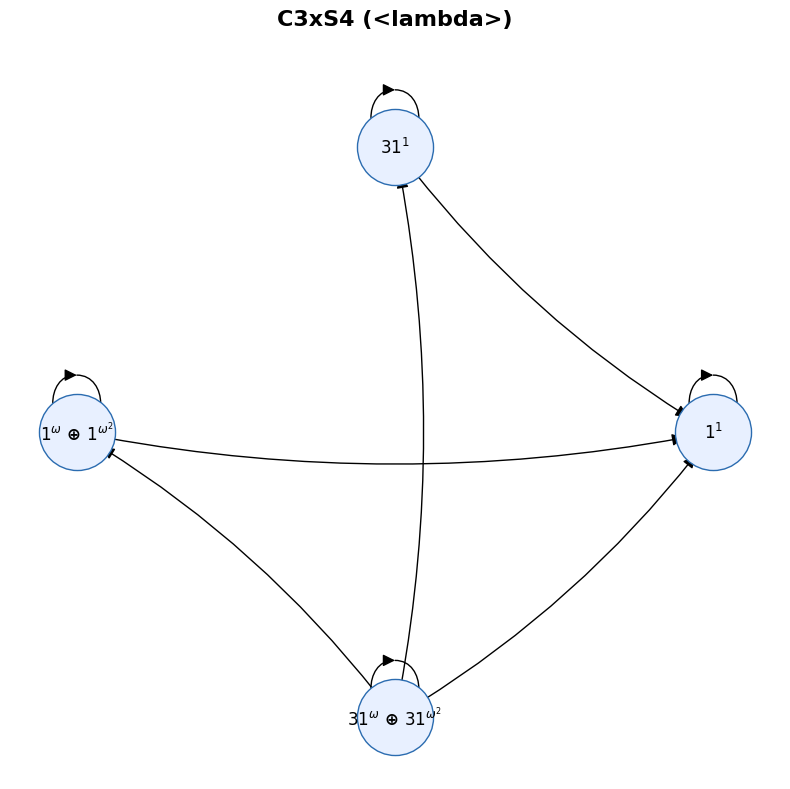

In [10]:
activation_fn = lambda x: x**2 + 2*x + 3

# --- RUN --- #

elements, mult_func = define_group()
classes_data = define_conjugacy_classes()

G = FiniteGroup(elements, mult_func, classes=classes_data)

# H = Stabilizer of '3' in S4 component, Trivial in C3 component
H_elements = define_subgroup(G)
solver = InducedRepSolver(G)
solver.set_subgroup(H_elements)

char_map, labels = define_character_table()
solver.load_character_table(char_map, labels=labels)

irrep_mats = build_irrep_mats(G)
solver.load_irrep_matrices(irrep_mats)
solver.compute_projectors(refine=False)

for label, Q in solver.Qblocks.items():
    if Q.shape[1] > 0:
        print(f"    Irrep '{label}' appears with dimension {Q.shape[1]}")


graph = solver.build_interaction_graph(activation_fn=activation_fn)
solver.visualise_interaction_graph(graph, activation_fn=activation_fn, group_name="C3xS4", node_size=3000)

In [5]:

for Q in {key: value for key, value in solver.Qblocks.items() if not value.shape[0] == 0}.values():
    print(Q.shape)


(12, 1)
(12, 3)
(12, 2)
(12, 6)


In [6]:
irrep_labels = ['$1^{1}$',
 '$1111^{1}$',
 '$22^{1}$',
 '$31^{1}$',
 '$211^{1}$',
 '$1^{\omega}$ ⊕ $1^{\omega^2}$',
 '$1111^{\omega}$ ⊕ $1111^{\omega^2}$',
 '$22^{\omega}$ ⊕ $22^{\omega^2}$',
 '$31^{\omega}$ ⊕ $31^{\omega^2}$',
 '$211^{\omega}$ ⊕ $211^{\omega^2}$']

Q_global = sp.Matrix.hstack(*[Q for Q in solver.Qblocks.values() if Q.shape[1] > 0])
Q_global_inv = Q_global.inv()

col_ranges = {}
start = 0

for L in irrep_labels:
    dim = solver.Qblocks[L].shape[1]
    if dim > 0:
        col_ranges[L] = (start, start + dim)
        start += dim

col_ranges

<>:6: SyntaxWarning: invalid escape sequence '\o'
<>:7: SyntaxWarning: invalid escape sequence '\o'
<>:8: SyntaxWarning: invalid escape sequence '\o'
<>:9: SyntaxWarning: invalid escape sequence '\o'
<>:10: SyntaxWarning: invalid escape sequence '\o'
<>:6: SyntaxWarning: invalid escape sequence '\o'
<>:7: SyntaxWarning: invalid escape sequence '\o'
<>:8: SyntaxWarning: invalid escape sequence '\o'
<>:9: SyntaxWarning: invalid escape sequence '\o'
<>:10: SyntaxWarning: invalid escape sequence '\o'
/var/folders/dv/1fh0mhbj1lq5yk_27yzzwc040000gn/T/ipykernel_1704/908022377.py:6: SyntaxWarning: invalid escape sequence '\o'
  '$1^{\omega}$ ⊕ $1^{\omega^2}$',
/var/folders/dv/1fh0mhbj1lq5yk_27yzzwc040000gn/T/ipykernel_1704/908022377.py:7: SyntaxWarning: invalid escape sequence '\o'
  '$1111^{\omega}$ ⊕ $1111^{\omega^2}$',
/var/folders/dv/1fh0mhbj1lq5yk_27yzzwc040000gn/T/ipykernel_1704/908022377.py:8: SyntaxWarning: invalid escape sequence '\o'
  '$22^{\omega}$ ⊕ $22^{\omega^2}$',
/var/folders/

{'$1^{1}$': (0, 1),
 '$31^{1}$': (1, 4),
 '$1^{\\omega}$ ⊕ $1^{\\omega^2}$': (4, 6),
 '$31^{\\omega}$ ⊕ $31^{\\omega^2}$': (6, 12)}

In [7]:
P = sp.Matrix([
    [0,1,0,0],
    [0,0,1,0],
    [0,0,0,1],
    [1,0,0,0],
])

C3_shift = sp.Matrix([
    [0,1,0],
    [0,0,1],
    [1,0,0],
])

M = sp.kronecker_product(C3_shift, P)

Q_global_inv * (M * Q_global).applyfunc(activation_fn)

Matrix([
[1,  3/4, 3/4, 3/4,  2/3, 2/3,    1,     1,     1,     1,    1,    1],
[0, -3/4, 3/4,   0,    0,   0, -1/3,   1/3,     0,  -1/3,  1/3,    0],
[0, -3/4,   0, 3/4,    0,   0, -1/3,     0,   1/3,  -1/3,    0,  1/3],
[0, -3/4,   0,   0,    0,   0, -1/3,     0,     0,  -1/3,    0,    0],
[0,    0,   0,   0, -2/3, 2/3, -1/4,  -1/4,  -1/4,   1/4,  1/4,  1/4],
[0,    0,   0,   0, -2/3,   0, -1/4,  -1/4,  -1/4,     0,    0,    0],
[0,    0,   0,   0,    0,   0, 7/12, -7/12,     0, -7/12, 7/12,    0],
[0,    0,   0,   0,    0,   0, 7/12,     0, -7/12, -7/12,    0, 7/12],
[0,    0,   0,   0,    0,   0, 7/12,     0,     0, -7/12,    0,    0],
[0,    0,   0,   0,    0,   0, 7/12, -7/12,     0,     0,    0,    0],
[0,    0,   0,   0,    0,   0, 7/12,     0, -7/12,     0,    0,    0],
[0,    0,   0,   0,    0,   0, 7/12,     0,     0,     0,    0,    0]])